In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

# Robert Swain

In [2]:
sample_size = 100
eligible_population = make_array(0.26, 0.74)

In [4]:
sample_proportions(sample_size, eligible_population)

array([ 0.23,  0.77])

In [9]:
sample_proportions(sample_size, eligible_population).item(0) * sample_size

31.0

In [10]:
def one_simulated_count():
    return sample_proportions(sample_size, eligible_population).item(0) * sample_size

In [11]:
one_simulated_count()

25.0

In [ ]:
# Crushed ICE: create an array called counts and add 10,000 simulated counts to it

In [12]:
counts = make_array()
repetitions = 10000
for i in np.arange(repetitions):
    counts = np.append(counts, one_simulated_count())

In [13]:
counts

array([ 19.,  27.,  21., ...,  18.,  30.,  27.])

In [15]:
Table().with_column('Count in a random sample', counts).sort(0)

Count in a random sample
12
12
13
13
13
13
13
13
13
13


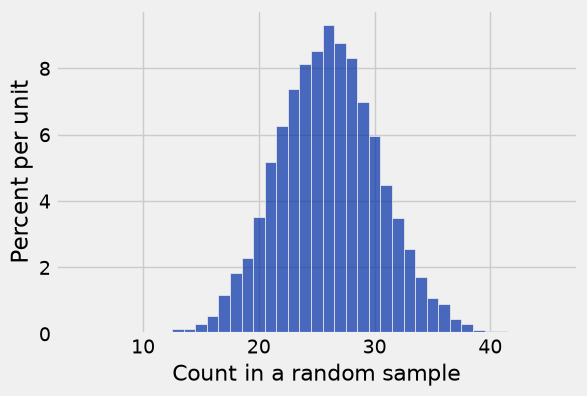

In [16]:
Table().with_column('Count in a random sample', counts).hist(bins=np.arange(4.5, 45.6, 1))

In [18]:
np.count_nonzero(counts == 8)

0

In [21]:
np.count_nonzero(counts <= 8)

0

# Jury Selection in Alameda County

In [22]:
jury = Table().with_columns(
    'Ethnicity', make_array('Asian/PI', 'Black/AA', 'Caucasian', 'Hispanic', 'Other'),
    'Eligible', make_array(0.15, 0.18, 0.54, 0.12, 0.01),
    'Panels', make_array(0.26, 0.08, 0.54, 0.08, 0.04),
)
jury

Ethnicity,Eligible,Panels
Asian/PI,0.15,0.26
Black/AA,0.18,0.08
Caucasian,0.54,0.54
Hispanic,0.12,0.08
Other,0.01,0.04


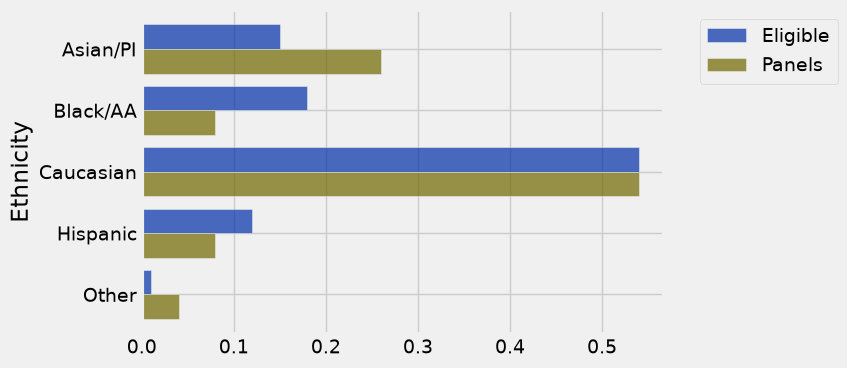

In [23]:
jury.barh('Ethnicity')

In [24]:
# Crushed ICE: There were 1,453 people on juries during the study.
# Using the proportions of the eligible jurors and sample_proportions, simulate picking
# 1,453 jurors
jury.column('Eligible')

array([ 0.15,  0.18,  0.54,  0.12,  0.01])

In [28]:
model = jury.column('Eligible')
simulated = sample_proportions(1453, model)
simulated

array([ 0.15760496,  0.17756366,  0.52993806,  0.12319339,  0.01169993])

In [29]:
jury_with_simulated = jury.with_column('Simulated', simulated)
jury_with_simulated

Ethnicity,Eligible,Panels,Simulated
Asian/PI,0.15,0.26,0.157605
Black/AA,0.18,0.08,0.177564
Caucasian,0.54,0.54,0.529938
Hispanic,0.12,0.08,0.123193
Other,0.01,0.04,0.0116999


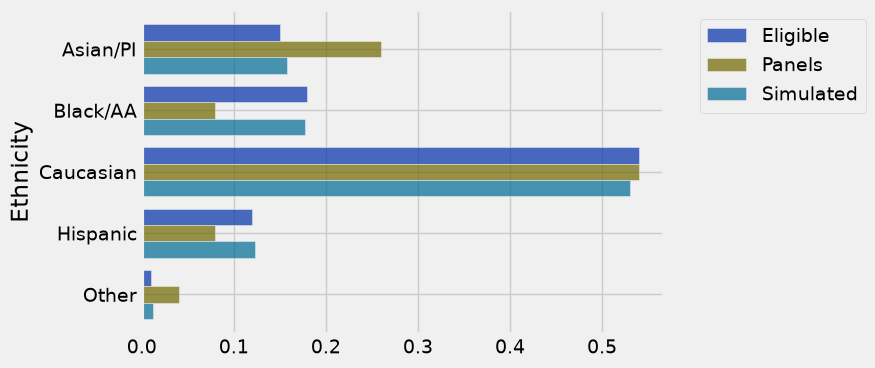

In [30]:
jury_with_simulated.barh('Ethnicity')

In [31]:
# There aren't just two things to compare! Goal: make *one number* to represent the
# differences. We need a new statistic to measure the difference between the
# distributions!

In [32]:
jury

Ethnicity,Eligible,Panels
Asian/PI,0.15,0.26
Black/AA,0.18,0.08
Caucasian,0.54,0.54
Hispanic,0.12,0.08
Other,0.01,0.04


In [34]:
diffs = jury.column('Panels') - jury.column('Eligible')
jury_with_difference = jury.with_column('Difference', diffs)
jury_with_difference

Ethnicity,Eligible,Panels,Difference
Asian/PI,0.15,0.26,0.11
Black/AA,0.18,0.08,-0.1
Caucasian,0.54,0.54,0
Hispanic,0.12,0.08,-0.04
Other,0.01,0.04,0.03


In [37]:
sum(jury_with_difference.where('Difference', are.above(0)).column('Difference'))

0.14000000000000001

In [44]:
sum(abs(jury_with_difference.column('Difference'))) / 2

0.14000000000000001

In [45]:
def tvd(dist1, dist2):
    return sum(abs(dist2 - dist1)) / 2

In [47]:
observed_tvd = tvd(jury.column('Eligible'), jury.column('Panels'))
observed_tvd

0.14000000000000001

In [51]:
tvd(jury.column('Eligible'), sample_proportions(1453, model))

0.017130075705437033

In [52]:
def simulated_tvd():
    return tvd(jury.column('Eligible'), sample_proportions(1453, model))

tvds = make_array()

# Crushed ICE: simulate 10,000 tvds into the tvds array
num_simulations = 10000
for i in np.arange(num_simulations):
    new_tvd = simulated_tvd()
    tvds = np.append(tvds, new_tvd)

In [53]:
len(tvds)

10000

In [54]:
tvds

array([ 0.0187956 ,  0.02507226,  0.01097729, ...,  0.02069511,
        0.03737784,  0.00539573])

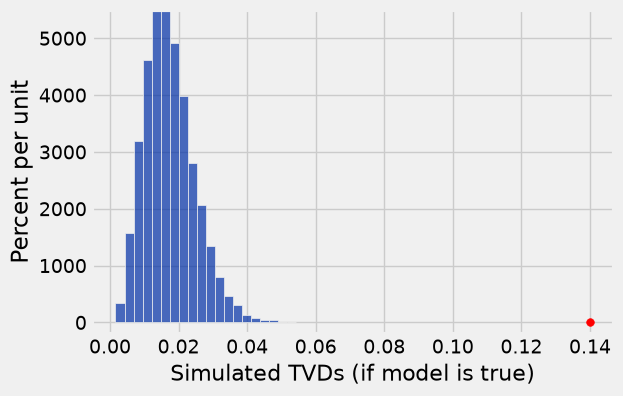

In [59]:
title = 'Simulated TVDs (if model is true)'

Table().with_column(title, tvds).hist(bins=20)

# Plotting the observed TVD--ignore this code!
plt.ylim(-2, 55)
plt.scatter(observed_tvd, 0, color='red', s=30)

In [60]:
np.count_nonzero(tvds >= 0.14)

0